In [5]:
import pandas as pd
import seaborn as sns
import sys, os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.append('../../scripts/signals_analysis')

from calculate import get_signals
from save import save_signals

# Notebook uses functions from .py scripts in scripts/ folder
sys.path.append('../../scripts/signals_analysis')

from calculate import get_signals
from save import save_signals

## Heatmaps for experiment with DMSO and IAA treatment
Use output from notebooks/compare_coordinates/1.2_compare_peaks_DMSO_IAA.ipynb

In [ ]:
#################### EXAMPLE USAGE ####################
################ PASTE YOUR PATHS INSTEAD #############
# Coordinates for all common DMSO/IAA peaks with unique DMSO peaks
DMSO_common_path = "../../results/compared_peaks/RDY421_G1_DMSO_25_nC_RDY421_G1_IAA_25_nC/in_DMSO_IAA_ex_IAA_unique.bed" # all peaks exluding unique IAA

# Coordinates for only unique IAA peaks
IAA_unique_path = "../../results/compared_peaks/RDY421_G1_DMSO_25_nC_RDY421_G1_IAA_25_nC/in_RDY421_G1_IAA_25_nC_ex_RDY421_G1_DMSO_25_nC.bed" # in_IAA_ex_DMSO path

# Signals files for DMSO and IAA
DMSO_wig_path = '../../../ChEC_Data_Complete/wig/spikein_mean/RDY421_G1_DMSO_25_nC_spikein_mean.wig'
IAA_wig_path = '../../../ChEC_Data_Complete/wig/spikein_mean/RDY421_G1_IAA_25_nC_spikein_mean.wig'

In [ ]:
# Retrieve signals based on coordinates
# Signals from DMSO sample
DMSO_signals_coord_DMSO_common = get_signals(DMSO_common_path, DMSO_wig_path)
DMSO_signals_coord_IAA_unique = get_signals(IAA_unique_path, DMSO_wig_path)

# Signals from IAA sample
IAA_signals_coord_DMSO_common = get_signals(DMSO_common_path, IAA_wig_path)
IAA_signals_coord_IAA_unique = get_signals(IAA_unique_path, IAA_wig_path)

Processing chromosome chrI..
Processing chromosome chrII..
Processing chromosome chrIII..
Processing chromosome chrIV..
Processing chromosome chrIX..
Processing chromosome chrV..
Processing chromosome chrVI..
Processing chromosome chrVII..
Processing chromosome chrVIII..
Processing chromosome chrX..
Processing chromosome chrXI..
Processing chromosome chrXII..
Processing chromosome chrXIII..
Processing chromosome chrXIV..
Processing chromosome chrXV..
Processing chromosome chrXVI..
Processing chromosome chrI..
Processing chromosome chrII..
Processing chromosome chrIII..
Processing chromosome chrIV..
Processing chromosome chrIX..
Processing chromosome chrV..
Processing chromosome chrVI..
Processing chromosome chrVII..
Processing chromosome chrVIII..
Processing chromosome chrX..
Processing chromosome chrXI..
Processing chromosome chrXII..
Processing chromosome chrXIII..
Processing chromosome chrXIV..
Processing chromosome chrXV..
Processing chromosome chrXVI..
Processing chromosome chrI..

In [8]:
# Sort both DataFrames in descending order by DMSO
DMSO_signals_coord_DMSO_common = DMSO_signals_coord_DMSO_common.T
DMSO_signals_coord_IAA_unique = DMSO_signals_coord_IAA_unique.T
DMSO_signals_coord_DMSO_common = DMSO_signals_coord_DMSO_common.loc[DMSO_signals_coord_DMSO_common.apply(sum, axis=1).sort_values(ascending=False).index]
DMSO_signals_coord_IAA_unique = DMSO_signals_coord_IAA_unique.loc[DMSO_signals_coord_IAA_unique.apply(sum, axis=1).sort_values(ascending=False).index]

# Sort both DataFrames in descending order by DMSO
IAA_signals_coord_DMSO_common = IAA_signals_coord_DMSO_common.T
IAA_signals_coord_IAA_unique = IAA_signals_coord_IAA_unique.T
IAA_signals_coord_DMSO_common = IAA_signals_coord_DMSO_common.loc[DMSO_signals_coord_DMSO_common.apply(sum, axis=1).sort_values(ascending=False).index]
IAA_signals_coord_IAA_unique = IAA_signals_coord_IAA_unique.loc[DMSO_signals_coord_IAA_unique.apply(sum, axis=1).sort_values(ascending=False).index]

In [11]:
def plot_pair_peaks(P1, P2):
    ''' Generate heatplots for pair of signals (DMSO and IAA).
    Color scale is the same for given pair, with max(P1,P2) and min(P1,P2).
    '''
    # Set font size globally for the figure
    plt.rcParams.update({'font.size': 13})
    
    fig = plt.figure(figsize=(8, 12))
    gs = gridspec.GridSpec(2, 2, height_ratios=[1, 4], wspace=0.1, hspace=0.1)

    vmax = max(P1.values.max(), P2.values.max())
    vmin = min(P1.values.min(), P2.values.min())

    meanmax = max(P1.mean(axis=0).max(), P2.mean(axis=0).max()) + 5
    # Set minimum to 0 instead of the actual minimum
    meanmin = 0

    # Top left plot
    ax1 = plt.subplot(gs[0])
    ax1.set_facecolor(color='whitesmoke')
    ax1.grid(False)
    ax1.plot(P1.mean(axis=0), color="blue", linewidth=2)
    ax1.set_ylabel('Average signal', fontsize=13)
    ax1.set_ylim(meanmin, meanmax)
    ax1.set(xticks=[0, 75, 151], xticklabels=['-75', '0', '75'])
    ax1.tick_params(left=True, labelsize=13)
    ax1.tick_params(axis='both', which='major', labelsize=13)

    # Bottom left plot (heatmap)
    ax2 = plt.subplot(gs[2])
    sns.heatmap(data=P1, cmap='Spectral_r', ax=ax2,
                vmin=vmin, vmax=vmax,
                cbar_kws={'aspect': 30, 'location': 'bottom', 
                         'shrink': 0.8, 'pad': 0.05})
    ax2.set(yticks=[])
    ax2.set_ylabel(f'n={P1.shape[0]}', fontsize=13)  # add number of peaks used for heatmaps
    ax2.set(xticks=[0, 75, 151], xticklabels=['-75', '0', '75'])
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0, fontsize=13)
    ax2.tick_params(bottom=True, labelsize=13)
    ax2.tick_params(axis='both', which='major', labelsize=13)
    
    # Adjust colorbar font size
    cbar = ax2.collections[0].colorbar
    cbar.ax.tick_params(labelsize=13)

    # Top right plot
    ax3 = plt.subplot(gs[1])
    ax3.set_facecolor(color='whitesmoke')
    ax3.grid(False)
    ax3.plot(P2.mean(axis=0), color="blue", linewidth=2)
    ax3.set_ylim(meanmin, meanmax)
    ax3.set_xlim(0, 151)
    ax3.set(xticks=[0, 75, 151], xticklabels=['-75', '0', '75'])
    ax3.set_yticks([])
    ax3.tick_params(bottom=True, labelsize=13)
    ax3.tick_params(axis='both', which='major', labelsize=13)

    # Bottom right plot (heatmap)
    ax4 = plt.subplot(gs[3])
    sns.heatmap(data=P2, cmap='Spectral_r', ax=ax4,
                vmin=vmin, vmax=vmax,
                cbar_kws={'aspect': 30, 'location': 'bottom', 
                         'shrink': 0.8, 'pad': 0.05})
    ax4.set(yticks=[])
    ax4.set_ylabel(f'n={P2.shape[0]}', fontsize=13)  # add number of peaks used for heatmaps
    ax4.set(xticks=[0, 75, 151], xticklabels=['-75', '0', '75'])
    ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0, fontsize=13)
    ax4.tick_params(bottom=True, labelsize=13)
    ax4.tick_params(axis='both', which='major', labelsize=13)
    
    # Adjust colorbar font size
    cbar = ax4.collections[0].colorbar
    cbar.ax.tick_params(labelsize=13)

    plt.tight_layout()
    plt.show()

/var/folders/lf/h7p_njl17ds2zx38ffpj5mb80000gw/T/ipykernel_25764/3190887721.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


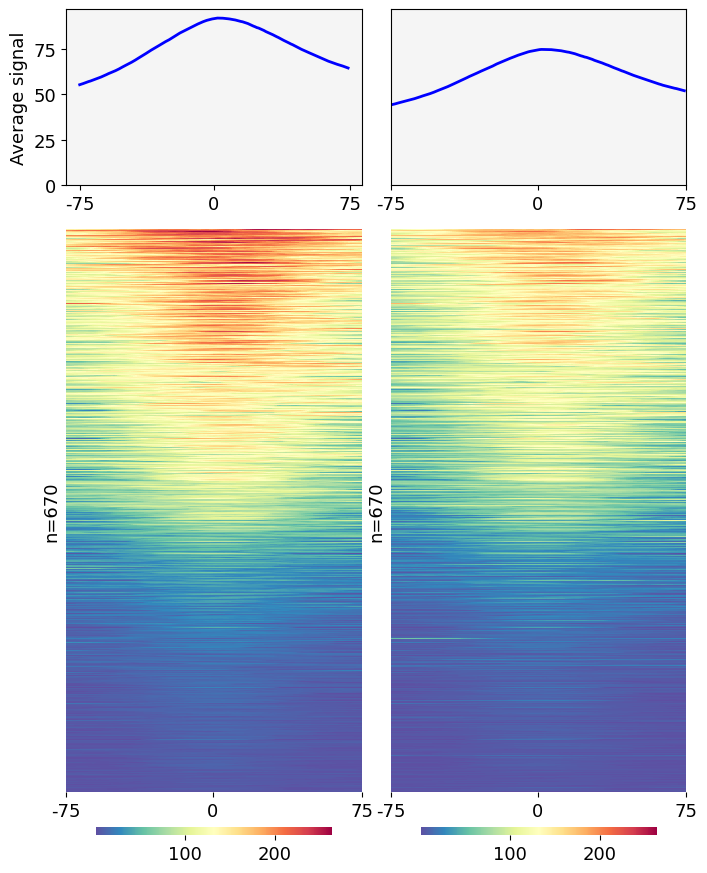

In [ ]:
plot_pair_peaks(DMSO_signals_coord_DMSO_common, IAA_signals_coord_DMSO_common) # Plot signals, coordinates form DMSO+common

/var/folders/lf/h7p_njl17ds2zx38ffpj5mb80000gw/T/ipykernel_25764/3190887721.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


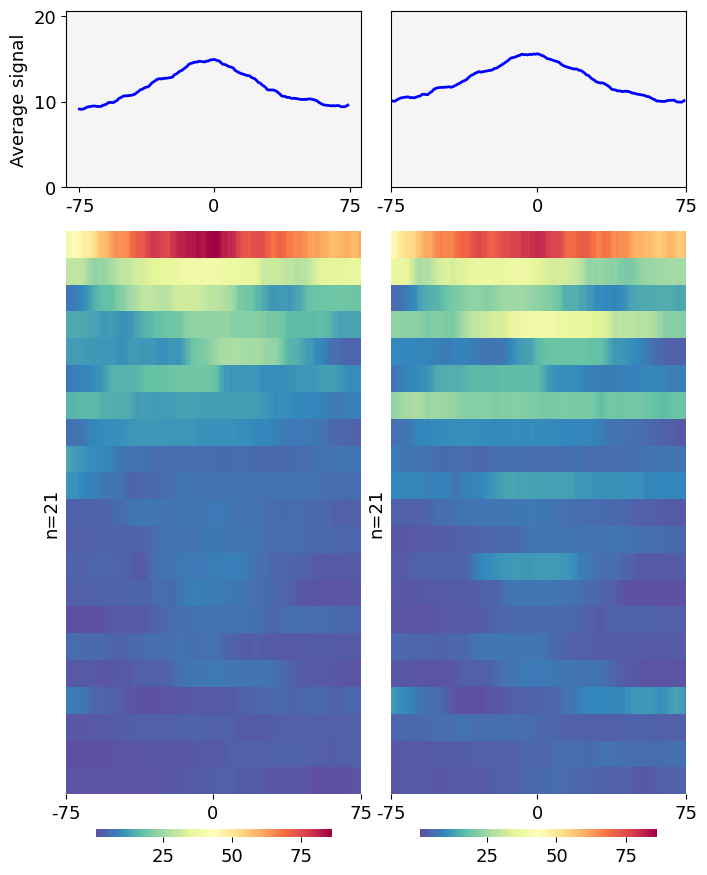

In [ ]:
plot_pair_peaks(DMSO_signals_coord_IAA_unique, IAA_signals_coord_IAA_unique) # Plot signals, coordinates form IAA unique